In [3]:
import numpy as np
import matplotlib.pyplot as plt
import math as mt

In [4]:
def plot_points(points_courbe,style):
    x = []
    y = []
    for p in points_courbe:
        x.append(p[0])
        y.append(p[1])
    plt.plot(x,y,style)

In [5]:
def courbe_bezier_bern(points_control,N):
    # On renvoie une liste de N tuples correspondants aux coordonnées de N points de la courbe
    result = []
    nb_point_controle = len(points_control)
    for i in range(N):
        t = i /(N-1)
        x =0 
        y =0 
        for j in range(nb_point_controle):
            b = mt.comb(nb_point_controle -1 ,j) * pow(1-t , nb_point_controle-1-j) * pow(t,j)
            x += b * points_control[j][0]
            y += b * points_control[j][1]
        result.append((x,y))
    return result

test courbe_bezier_bern :  True


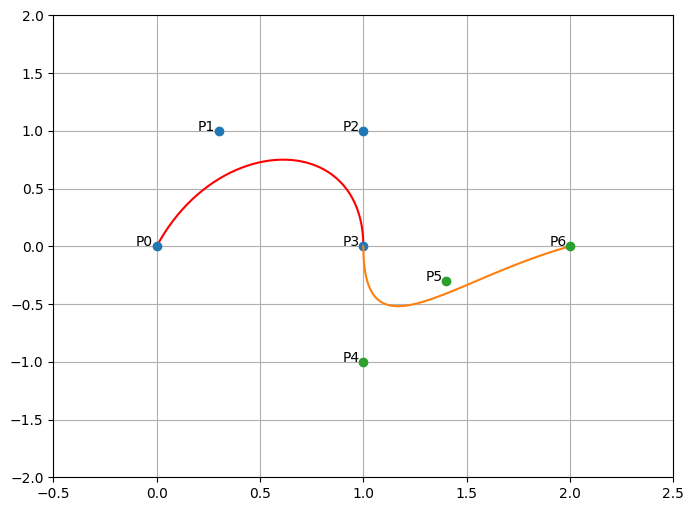

In [6]:
plt.figure(figsize=(8,6))
P0 = (0,0)
P1 = (0.3,1)
P2 = (1,1)
P3 = (1,0)
P4 = (1,-1)
P5 = (1.4,-0.3)
P6 = (2,0)
Points=[P0,P1,P2,P3,P4,P5,P6]
#Points=[globals()['P'+str(i)] for i in range(7)]

res = courbe_bezier_bern(Points[:4],50)
test_res=[(0.0, 0.0), (0.01885778884648403, 0.05997501041232819), (0.03865906212547492, 0.11745106205747603), (0.05934772076260742, 0.17242815493544358), (0.08086766568351621, 0.22490628904623072), (0.10316279781383604, 0.2748854643898375), (0.12617701807920167, 0.322365680966264), (0.14985422740524781, 0.3673469387755103), (0.17413832671760915, 0.409829237817576), (0.19897321694192047, 0.4498125780924615), (0.2243027990038164, 0.48729695960016645), (0.2500709738289318, 0.5222823823406914), (0.2762216423429013, 0.5547688463140358), (0.30269870547135963, 0.5847563515201998), (0.3294460641399417, 0.6122448979591837), (0.35640761927428194, 0.6372344856309871), (0.3835272718000153, 0.6597251145356101), (0.4107489226427764, 0.679716784673053), (0.4380164727281999, 0.6972094960433153), (0.46527382298192077, 0.7122032486463974), (0.4924648743295734, 0.7246980424822989), (0.519533527696793, 0.7346938775510203), (0.5464236840092138, 0.7421907538525614), (0.5730792441924707, 0.747188671386922), (0.5994441091721987, 0.7496876301541024), (0.6254621798740321, 0.7496876301541024), (0.6510773572236056, 0.747188671386922), (0.6762335421465545, 0.7421907538525614), (0.7008746355685131, 0.7346938775510206), (0.7249445384151162, 0.7246980424822991), (0.7483871516119983, 0.7122032486463974), (0.7711463760847945, 0.6972094960433154), (0.7931661127591394, 0.6797167846730529), (0.8143902625606677, 0.6597251145356102), (0.8347627264150141, 0.6372344856309871), (0.8542274052478134, 0.6122448979591838), (0.8727281999847002, 0.5847563515202), (0.8902090115513094, 0.5547688463140359), (0.9066137408732755, 0.5222823823406915), (0.9218862888762335, 0.4872969596001668), (0.935970556485818, 0.44981257809246167), (0.9488104446276636, 0.40982923781757613), (0.9603498542274053, 0.36734693877551033), (0.9705326862106775, 0.32236568096626406), (0.9793028415031151, 0.27488546438983785), (0.986604221030353, 0.22490628904623094), (0.9923807257180257, 0.17242815493544372), (0.9965762564917678, 0.11745106205747619), (0.9991347142772145, 0.059975010412328264), (1.0, 0.0)]
test_res=[list(t) for t in test_res]
res=[list(t) for t in res]
print('test courbe_bezier_bern : ',np.count_nonzero(np.isclose(test_res,res))==len(res)*2)
plot_points(res,'r-')
plot_points([P0,P1,P2,P3],'o')

points2 = courbe_bezier_bern(Points[3:],50)
plot_points(points2,'-')
plot_points([P4,P5,P6],'o')

for i in range(7):
    plt.annotate('P'+str(i), xy=(Points[i][0], Points[i][1]), xytext=(Points[i][0]-0.1, Points[i][1]))
plt.axis([-0.5,2.5,-2,2])
plt.grid()
plt.show()

In [7]:
def bary(A,B,t):
    a = np.outer((1-t),A)
    res = a + np.outer(t,B)
    return res

In [8]:
res=bary(P4,P5,0.6)
test_res=(1.24, -0.58)
print('test bary : ',np.count_nonzero(np.isclose(list(res),list(test_res)))==2)

test bary :  True


In [9]:
def reduction(points_control,t):
    liste=[]
    for  i in range(len(points_control)-1):
        liste.append(bary(points_control[i],points_control[i+1],t))
    return liste

In [10]:
res=reduction([P0,P1,P2,P3],0.7)
test_res=[(0.21, 0.7), (0.7899999999999999, 1.0), (1.0, 0.30000000000000004)]
test_res=[list(t) for t in test_res]
res=[list(t) for t in res]
print('test reduction : ',np.count_nonzero(np.isclose(res,test_res))==len(test_res)*2)

test reduction :  True


In [11]:
def point_bezier_geom(points_control,t):
    for i in range(len(points_control)-1):
        points_control = reduction(points_control,t)
    return points_control

In [12]:
res=point_bezier_geom([P0,P1,P2,P3],0.7)
test_res=(0.8406999999999999, 0.63)
print('test point_bezier_geom : ',np.count_nonzero(np.isclose(list(res),list(test_res)))==2)

test point_bezier_geom :  True


In [13]:
def courbe_bezier_geom(points_control,N):
    result = []
    for i in range(N):
        t = i /(N-1)
        result.append(point_bezier_geom(points_control,t))
    return result

In [14]:
res=courbe_bezier_geom([P0,P1,P2],10)
test_res=[(0.0, 0.0), (0.07160493827160493, 0.20987654320987653), (0.1530864197530864, 0.3950617283950617), (0.2444444444444444, 0.5555555555555556), (0.345679012345679, 0.691358024691358), (0.45679012345679015, 0.8024691358024691), (0.5777777777777777, 0.8888888888888888), (0.7086419753086418, 0.9506172839506173), (0.8493827160493826, 0.9876543209876543), (1.0, 1.0)]
test_res=[list(t) for t in test_res]
res=[list(t) for t in res]
print('test courbe_bezier_geom : ',np.count_nonzero(np.isclose(test_res,res))==len(res)*2)

test courbe_bezier_geom :  True


In [17]:
plt.figure(figsize=(8,6))
A0=(-1.5,-1.5)
A1=(-1,-0.8)
A2=(-0.5,-0.5)
A3=(0,-0.5)
plot_points(courbe_bezier_geom([A0,A1,A2,A3],50),style='-')
plot_points([A0,A1,A2,A3],style='o')
plt.axis([-2,0.5,-2,0.5])
plt.grid()
plt.show()

IndexError: list index out of range

<Figure size 800x600 with 0 Axes>

In [ ]:
def vecteur_unitaire(P1,P2):
    return

In [ ]:
res=vecteur_unitaire(P1,P5)
test_res=(0.6459422414661738, -0.7633862853691146)
print('test vecteur_unitaire : ',np.count_nonzero(np.isclose(list(res),list(test_res)))==2)

In [ ]:
def test_alignement_4pts(points,epsilon):
    return

In [ ]:
points1=[(0.9110260009765625, 0.5126953125), (0.918951416015625, 0.4951171875), (0.92642822265625, 0.4765625), (0.9334228515625, 0.45703125)]
points2=[(0.9693359375, 0.328125), (0.9890625, 0.234375), (1.0, 0.125), (1, 0)]
epsilon=0.005
print('test test_alignement_4pts : ',test_alignement_4pts(points1,epsilon)==True)
print('test test_alignement_4pts : ',test_alignement_4pts(points2,epsilon)==False)

In [ ]:
def division_courbe_bezier(points_control):
    return

In [ ]:
res=division_courbe_bezier([P0,P1,P2,P3])
test_res=([(0, 0), (0.15, 0.5), (0.4, 0.75), (0.6125, 0.75)], [(0.6125, 0.75), (0.825, 0.75), (1.0, 0.5), (1, 0)])
test_res=[list(t) for t in test_res]
res=[list(t) for t in res]
print('test division_courbe_bezier : ',np.count_nonzero(np.isclose(test_res,res))==np.array(res).size)

In [ ]:
def courbe_bezier_cast_helper(points_control,epsilon,points_courbe):
    return

In [ ]:
def courbe_bezier_cast(points_control,epsilon):
    return

In [ ]:
P0 = (0,0)
P1 = (0.3,1)
P2 = (1,1)
P3 = (1,0)
plt.figure()
epsilon=5e-3
points = courbe_bezier_3_cast([P0,P1,P2,P3],epsilon)
plot_points(points,style='.')
plot_points(points,style='r-')
plot_points([P0,P1,P2,P3],style='o')
plt.axis([0,2,0,2])
plt.grid()
plt.show()

In [ ]:
P0 = (0,0)
P1 = (0.3,1)
P2 = (1,1)
P3 = (1,0)
epsilon=0.05
res = courbe_bezier_cast([P0,P1,P2,P3],epsilon)
test_res=[(0, 0), (0.2828125, 0.5625), (0.4482421875, 0.703125), (0.5313232421875, 0.73828125), (0.6125, 0.75), (0.6901611328125, 0.73828125), (0.7626953125, 0.703125), (0.8284912109375, 0.64453125), (0.8859375, 0.5625), (0.9693359375, 0.328125), (1, 0)]
test_res=[list(t) for t in test_res]
res=[list(t) for t in res]
print('test courbe_bezier_cast : ',np.count_nonzero(np.isclose(test_res,res))==len(res)*2)
'''plot_points(res,style='.')
plot_points(res,style='r-')
plot_points([P0,P1,P2,P3],style='o')
plt.axis([0,2,0,2])
plt.grid()
plt.show()'''

In [ ]:
points_char_a=[(153,-12),(95,-12),(37,39),(37,115),\
               #P0->P4
               (37,227),(146,277),(264,325),\
               #P3->P6
               (330,352),\
               #P6P7
               (330,407),\
               #P7P8
               (330,474),(308,516),(243,516),\
               #P8->P11
               (202,516),(165,493),(165,459),\
               #P11->P14
               (165,449),(168,430),(168,420),\
               #P14->P17
               (168,378),(147,360),(114,360),\
               #P17->P20
               (83,360),(61,385),(61,417),\
               #P20->P23
               (61,478),(126,551),(253,551),\
               #P23->P26
               (415,551),(431,449),(431,362),\
               #P26->P29
               (431,147),\
               #P29P30
               (431,85),(434,59),(468,59),\
               #P30->P33
               (479,59),(484,64),(512,80),\
               #P33->P36
               (512,43),\
               #P36P37
               (458,2),(448,-12),(415,-12),\
               (346,-12),(337,32),(330,69),\
               (294,39),(244,-12),(153,-12)]

points_char_a2=[(143,153),(143,94),(178,60),(220,60),\
                #Q0->Q3
                (277,60),(310,95),(330,113),\
                #Q3->Q6
                (330,313),\
                #Q6Q7
                (269,288),\
                #Q7Q8
                (207,263),(143,221),(143,153)]
                #Q8->Q9
                
plt.figure(figsize=(8,6))

fonc_utilisee=courbe_bezier_geom
precision=50

plot_points(fonc_utilisee(points_char_a[:4],precision),style='b-')
#plot_points(points_char_a[:4],style='o')
plot_points(fonc_utilisee(points_char_a[3:7],precision),style='b-')
#plot_points(points_char_a[6:9],style='o')
plot_points(points_char_a[6:9],style='b-')#segments P6P7 et P7P8
plot_points(fonc_utilisee(points_char_a[8:12],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[11:15],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[14:18],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[17:21],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[20:24],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[23:27],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[26:30],precision),style='b-')
plot_points(points_char_a[29:31],style='b-')
plot_points(fonc_utilisee(points_char_a[30:34],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[33:37],precision),style='b-')
plot_points(points_char_a[36:38],style='b-')
plot_points(fonc_utilisee(points_char_a[37:41],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[40:44],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[43:47],precision),style='b-')
plot_points(fonc_utilisee(points_char_a[:4],precision),style='b-')

plot_points(fonc_utilisee(points_char_a2[:4],precision),style='b-')
plot_points(fonc_utilisee(points_char_a2[3:7],precision),style='b-')
plot_points(points_char_a2[6:8],style='b-')
plot_points(points_char_a2[7:9],style='b-')
plot_points(fonc_utilisee(points_char_a2[8:12],precision),style='b-')
plt.grid()
plt.show()